In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df=pd.read_json("A.json")
df.head()

,country,indicator,date,year_week,value,source,url
0,Austria,Daily hospital occupancy,2020-04-01,2020-W14,856.0,Country_Website,
1,Austria,Daily hospital occupancy,2020-04-02,2020-W14,823.0,Country_Website,
2,Austria,Daily hospital occupancy,2020-04-03,2020-W14,829.0,Country_Website,
3,Austria,Daily hospital occupancy,2020-04-04,2020-W14,826.0,Country_Website,
4,Austria,Daily hospital occupancy,2020-04-05,2020-W14,712.0,Country_Website,


In [79]:
df.shape

(28337, 7)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28337 entries, 0 to 28336
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   country    28337 non-null  object        
 1   indicator  28337 non-null  object        
 2   date       28337 non-null  datetime64[ns]
 3   year_week  28337 non-null  object        
 4   value      28337 non-null  float64       
 5   source     28337 non-null  object        
 6   url        19997 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 1.5+ MB


In [81]:
df.isnull().sum()

country         0
indicator       0
date            0
year_week       0
value           0
source          0
url          8340
dtype: int64

In [82]:
df=df.drop(columns=['url'])

In [83]:
df['date']=pd.to_datetime(df['date'])

In [84]:
len(df)

28337

In [85]:
df['country'].nunique()

25

In [86]:
df['indicator'].unique()

array(['Daily hospital occupancy', 'Daily ICU occupancy',
       'Weekly new hospital admissions per 100k',
       'Weekly new ICU admissions per 100k'], dtype=object)

In [93]:
df = df[df['indicator'] == 'Daily hospital occupancy']

In [94]:
df.shape

(12419, 6)

In [95]:
top_country=df.groupby('country')['value'].sum().sort_values(ascending=False).head(10)
print(top_country)

country
Spain        4033912.0
Romania      3420712.0
France       2936281.0
Czechia      2205796.0
Belgium      2048402.0
Austria      1218890.0
Slovakia     1124873.0
Bulgaria      408944.0
Lithuania     394655.0
Slovenia      365542.0
Name: value, dtype: float64


In [97]:
df.groupby('country')['value'].mean().sort_values(ascending=False).head(10)

country
France         16972.722543
Spain           9064.970787
Romania         4308.201511
Bulgaria        2175.234043
Czechia         1794.789260
Belgium         1778.126736
Austria         1027.731872
Slovakia        1011.576439
Netherlands      685.632653
Lithuania        642.760586
Name: value, dtype: float64

<Axes: xlabel='date'>

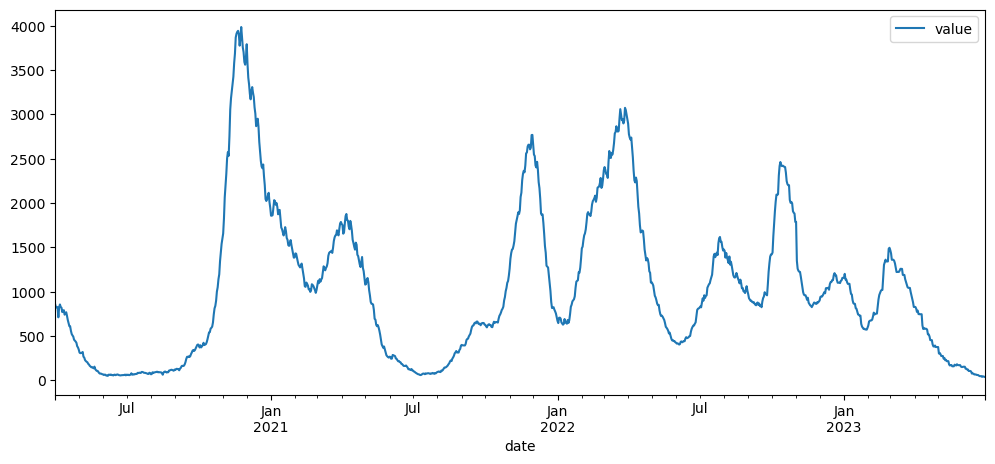

In [98]:
austria=df[df['country']=="Austria"]
austria.plot(x='date',y='value',figsize=(12,5))

In [99]:
arr=np.array(df['value'])
print("Mean:",np.mean(arr))
print("Median:",np.median(arr))
print("Max:",np.max(arr))

print("Std:",np.std(arr))

Mean: 1509.8916982043643
Median: 312.0
Max: 36404.0
Std: 3458.1494401359746


In [100]:
df.loc[df["value"].idxmax()]

country                        France
indicator    Daily hospital occupancy
date              2022-02-06 00:00:00
year_week                    2022-W05
value                         36404.0
source              TESSy RESPISEVERE
Name: 11760, dtype: object

<Axes: title={'center': 'Top 10 Countries by Hospital Occupancy'}, xlabel='country'>

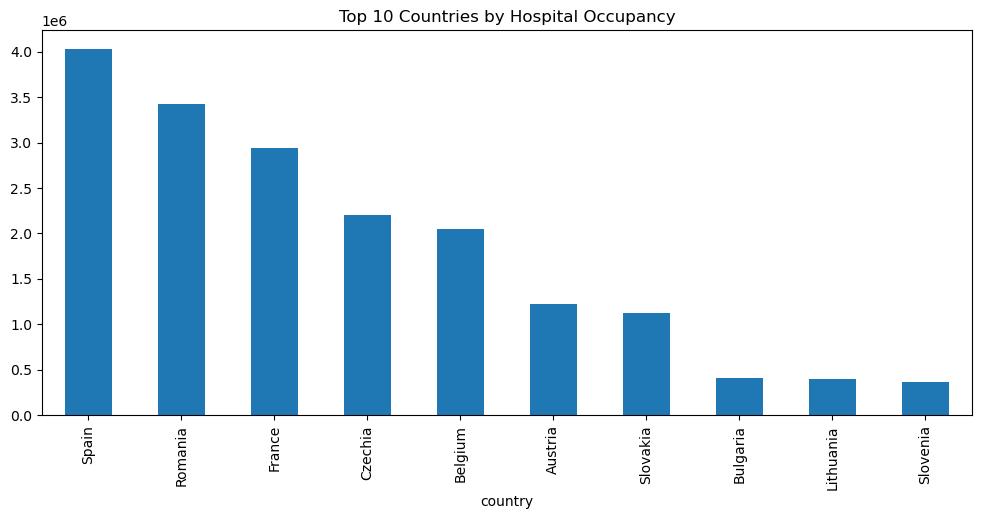

In [104]:
top10=df.groupby('country')['value'].sum().sort_values(ascending=False).head(10)
top10.plot(kind='bar',figsize=(12,5),title='Top 10 Countries by Hospital Occupancy')

<Axes: title={'center': 'Monthly Hospital Occupancy Trend'}, xlabel='date'>

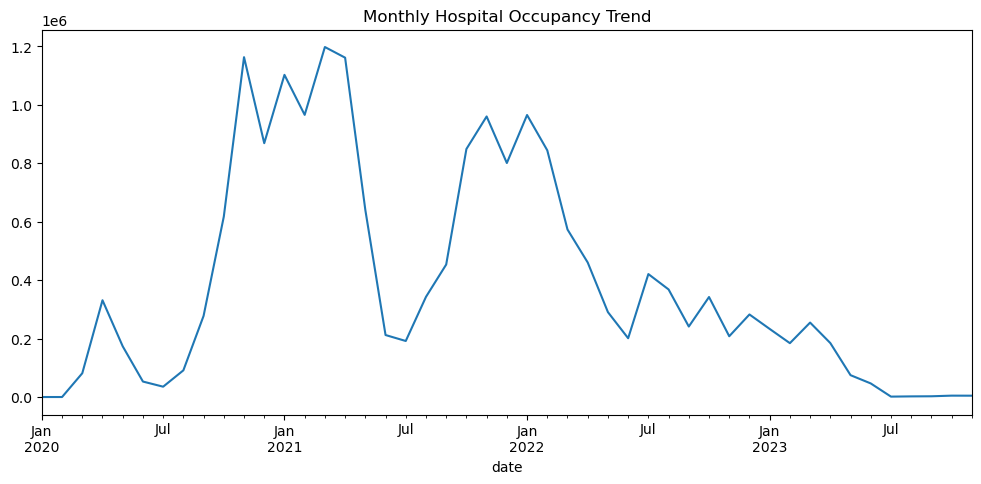

In [105]:
monthly=df.resample('M',on='date')['value'].sum()
monthly.plot(figsize=(12,5),title='Monthly Hospital Occupancy Trend')

<Axes: title={'center': 'Occupancy Distribution'}, ylabel='Frequency'>

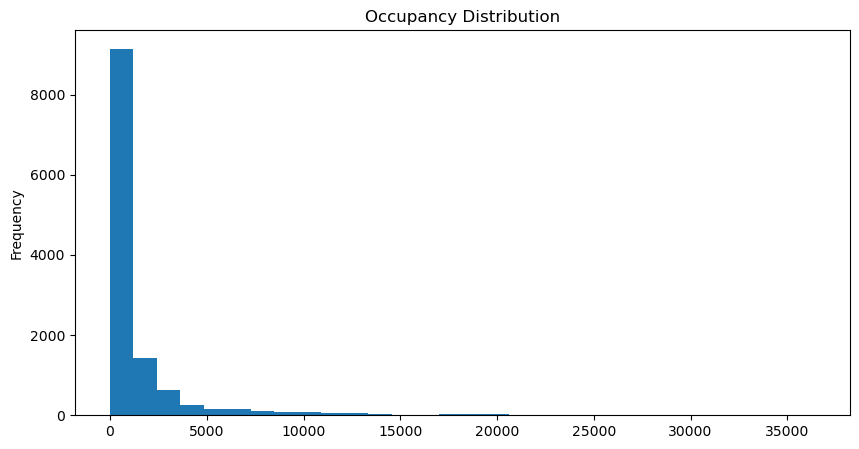

In [106]:
df['value'].plot(kind='hist',bins=30,figsize=(10,5),title='Occupancy Distribution')

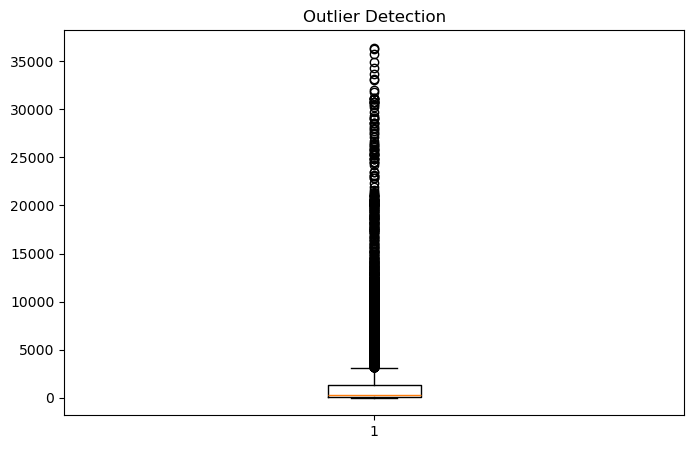

In [107]:
plt.figure(figsize=(8,5))
plt.boxplot(df['value'])
plt.title("Outlier Detection")
plt.show()